# Airline Passenger Demand Forecasting — Time Series Analysis

**Author:** Sabyasachi Sarkar

## Objective
Airlines need accurate passenger demand forecasts to plan budgets, staffing, and resource allocation ahead of time. In this project, I forecast future monthly passenger counts for an airline using historical data (1949–1960), applying and comparing 13 different time series forecasting techniques — from simple baselines to full seasonal ARIMA models.

## Problem Statement
> Given historical monthly passenger count data for an airline, forecast future passenger counts to support demand planning.

## Data Description
The dataset (the well-known AirPassengers dataset) contains monthly passenger counts for a commercial airline from 1949 to 1960.

| Attribute | Description |
|---|---|
| Month | The month of the record (yyyy-mm format) |
| Passengers | Number of air passengers in that month |

## Approach
1. Prepare the data for time series modelling (datetime conversion, sorting, train/test split)
2. Build and compare 13 forecasting models across four families:
   - **Baselines:** Linear regression, Naive, Simple average, Simple moving average
   - **Exponential smoothing:** Simple exponential smoothing, Holt's, Holt-Winters' additive, Holt-Winters' multiplicative
   - **Autoregressive family:** AR, MA, ARMA, ARIMA, SARIMA
3. Evaluate every model on held-out test data using RMSE and MAPE, and identify the best-performing approach


## Part 1 — Setup and Data Preparation
Importing the required libraries, loading the data, and preparing it for time series modelling (datetime conversion, chronological sorting, indexing).


In [4]:
# Import 'numpy' and 'pandas' for working with numbers and dataframes
import numpy as np
import pandas as pd

# Import 'pyplot' from 'matplotlib' and 'seaborn' for visualisations
from matplotlib import pyplot as plt
import seaborn as sns

# Import 'seasonal_decompose' from 'statsmodels' for seasonal decomposition of time series
from statsmodels.tsa.seasonal import seasonal_decompose

# Import 'LinearRegression' from 'sklearn' for building regression models
from sklearn.linear_model import LinearRegression

# Import 'SimpleExpSmoothing' from 'statsmodels' for simple exponential smoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Import 'ExponentialSmoothing' from 'statsmodels' for exponential smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Import 'mean_squared_error' from 'sklearn' for error computations
from sklearn.metrics import mean_squared_error

# Import 'plot_acf' from 'statsmodels' to compute and visualise the autocorrelation function (ACF) for the time series
from statsmodels.graphics.tsaplots import plot_acf

# Import 'plot_pacf' from 'statsmodels' to compute and visualise the partial autocorrelation function (ACF) for the time series
from statsmodels.graphics.tsaplots import plot_pacf

# Import the 'boxcox' method from 'scipy' to implement the Box-Cox transformation
from scipy.stats import boxcox

# Import 'ARIMA' from 'statsmodels' for building autoregressive models
from statsmodels.tsa.arima.model import ARIMA

# Import 'SARIMAX' from 'statsmodels' for building autoregressive models
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Import and execute method for suppressing warnings
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)

In [5]:
# Load the data directly from a public URL to ensure it is always available
df = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv')
df.columns = ['Month', 'Passengers']
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [6]:
# View specifics of the data frame using the '.info()' method
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Convert the 'Month' feature to the 'datetime' data type using the '.to_datetime()' method
df['Month'] = pd.to_datetime(df['Month'])

In [9]:
# View specifics of the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [10]:
# Ensure that the data are ordered chronologically using the '.sort_values()' method
df.sort_values(by = 'Month', inplace = True)

In [11]:
# Set the index of the data frame to 'Month' using the '.set_index()' method
df.set_index(keys = 'Month', inplace = True, drop = False)

In [12]:
# Take a look at the data using the '.head()' method
df.head()

,Month,Passengers
Month,,
1949-01-01,1949-01-01,112
1949-02-01,1949-02-01,118
1949-03-01,1949-03-01,132
1949-04-01,1949-04-01,129
1949-05-01,1949-05-01,121


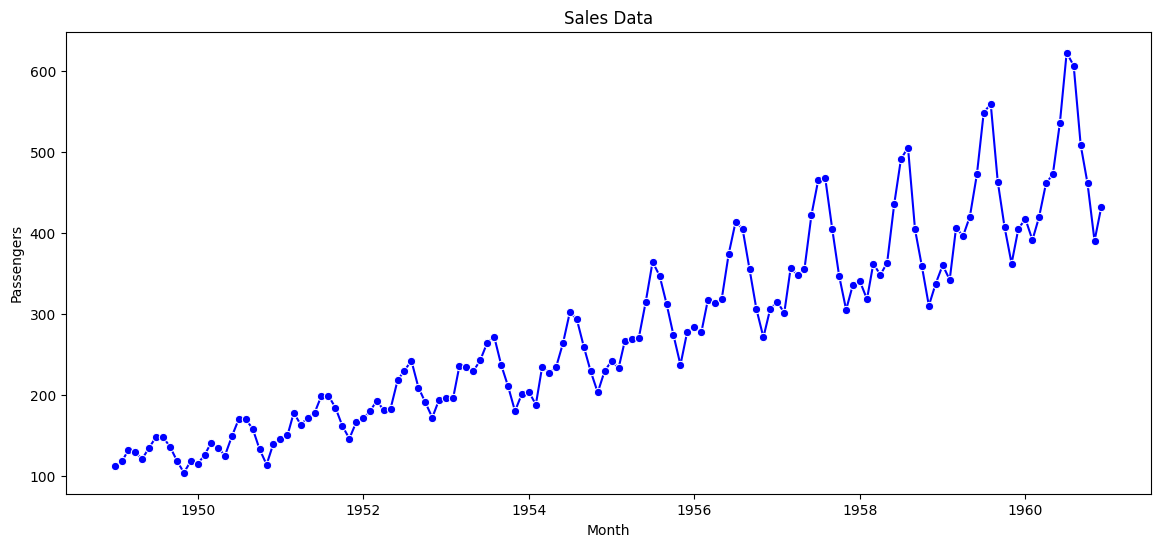

In [13]:
# Plot the time series data
plt.figure(figsize = (14, 6))
sns.lineplot(data = df, x = 'Month', y = 'Passengers', marker = 'o', color = 'blue')
plt.title('Sales Data');

In [14]:
# Take a look at the shape of the data using the '.shape' attribute
df.shape

(144, 2)

In [15]:
# Split the data into training and testing data sets
train_len = 120
df_train = df[:train_len] # first 120 months as training set
df_test = df[train_len:] # last 24 months as out-of-time test set

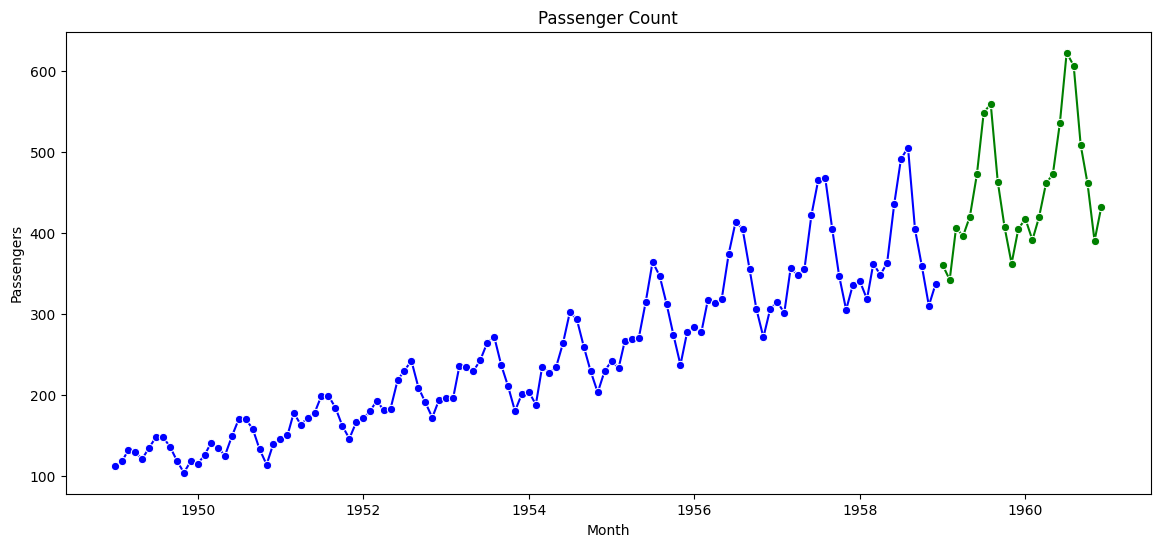

In [16]:
# Plot the time series data with the train-test split
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', marker = 'o', color = 'blue')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', marker = 'o', color = 'green')
plt.title('Passenger Count');

## Part 2 — Baseline Time Series Models
Before reaching for more complex techniques, I started with four simple baseline models to establish a performance floor: Linear regression, Naive, Simple average, and Simple moving average.


### 2.1 Linear Regression Method


In [17]:
# Create the independent variable for the linear regression model
linreg_X = np.arange(train_len)

In [18]:
# Convert the training variables into 2D arrays using the '.reshape()' method
linreg_X = linreg_X.reshape(-1, 1)
linreg_y = np.array(df_train['Passengers']).reshape(-1, 1)

In [19]:
# Create and fit a linear regression model to the training data using the 'LinearRegression()' and the '.fit()' methods
linreg_model = LinearRegression()
linreg_model.fit(linreg_X, linreg_y)

LinearRegression()

In [20]:
# Create the independent variable for the complete data set and reshape it accordingly
linreg_X_all = np.arange(df.shape[0])
linreg_X_all = linreg_X_all.reshape(-1, 1)

In [21]:
# Generate the complete regression line including both the training and testing data using the '.predict()' method
y_pred_lr = linreg_model.predict(linreg_X_all)

In [22]:
# Convert the predictions into a 1D array using the '.reshape()' method
y_pred_lr = y_pred_lr.reshape(-1)

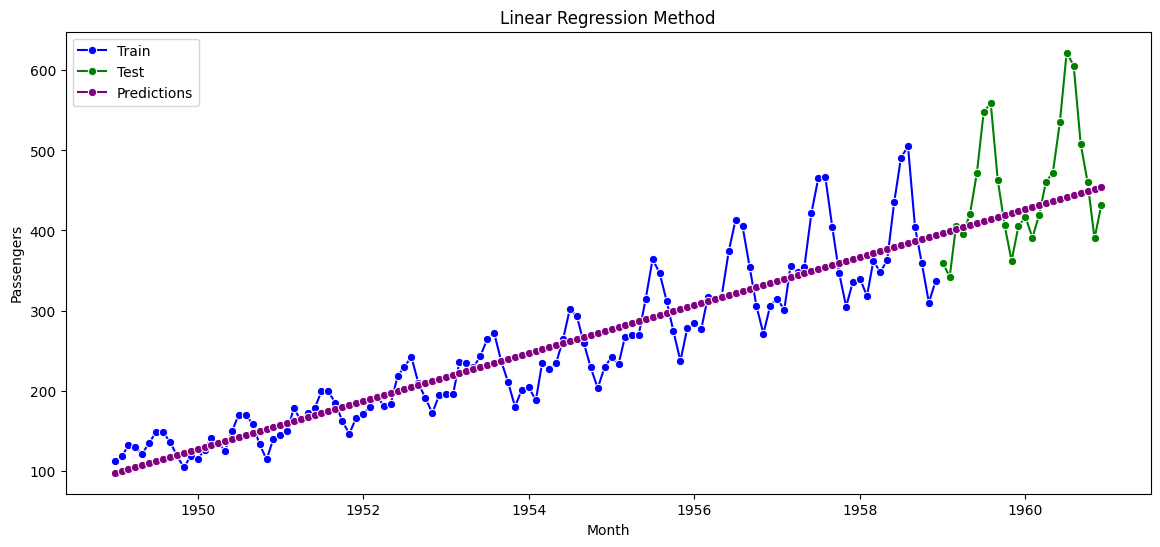

In [23]:
# Visualise the time series data and the predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', label = 'Train', marker = 'o', color = 'blue')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', label = 'Test', marker = 'o', color = 'green')
sns.lineplot(data = df, x = 'Month', y = y_pred_lr, label = 'Predictions', marker = 'o', color = 'purple')
plt.legend(loc = 'best')
plt.title('Linear Regression Method');

In [24]:
# Summarise the performance of the model on the test data using RMSE and MAPE
y_pred_lr_list = y_pred_lr[train_len:]

rmse = np.sqrt(mean_squared_error(y_true = df_test['Passengers'], y_pred = y_pred_lr_list))
mape = np.mean(np.abs(df_test['Passengers'] - y_pred_lr_list) / df_test['Passengers']) * 100

rmse = np.round(rmse, 2)
mape = np.round(mape, 2)

performance_df = pd.DataFrame(index = [0],
                              data = {'Model': 'Linear Regression', 'RMSE': rmse, 'MAPE': mape})

performance_df.set_index(keys = 'Model', inplace = True)

performance_df

,RMSE,MAPE
Model,,
Linear Regression,74.79,11.22


### 2.2 Naive Method


In [25]:
# Generate predictions for the test data for the naive method
y_pred_n = df_train['Passengers'].iloc[-1]

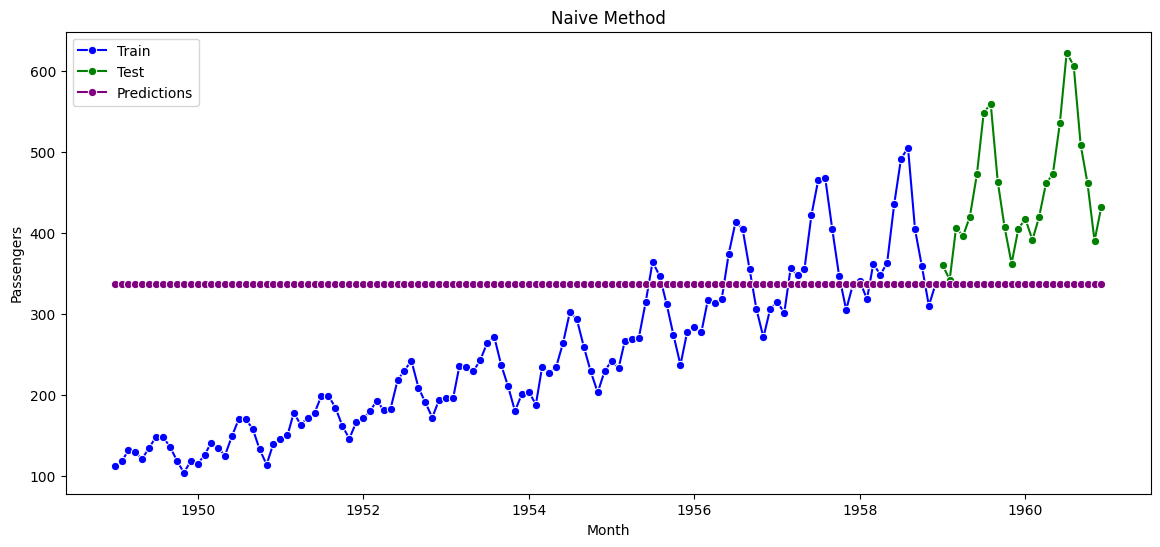

In [26]:
# Visualise the time series data and the predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', label = 'Train', marker = 'o', color = 'blue')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', label = 'Test', marker = 'o', color = 'green')
sns.lineplot(data = df, x = 'Month', y = y_pred_n, label = 'Predictions', marker = 'o', color = 'purple')
plt.legend(loc = 'best')
plt.title('Naive Method');

In [27]:
# Summarise the performance of the model on the test data using RMSE and MAPE
y_pred_n_list = [y_pred_n] * len(df_test)

rmse = np.sqrt(mean_squared_error(y_true = df_test['Passengers'], y_pred = y_pred_n_list))
mape = np.mean(np.abs(df_test['Passengers'] - y_pred_n_list) / df_test['Passengers']) * 100

rmse = np.round(rmse, 2)
mape = np.round(mape, 2)

performance_df_temp = pd.DataFrame(index = [0],
                                   data = {'Model': 'Naive', 'RMSE': rmse, 'MAPE': mape})

performance_df_temp.set_index(keys = 'Model', inplace = True)

performance_df = pd.concat(objs = [performance_df, performance_df_temp])

performance_df

,RMSE,MAPE
Model,,
Linear Regression,74.79,11.22
Naive,137.33,23.58


### 2.3 Simple Average Method


In [28]:
# Generate predictions for the test data using the simple average method
y_pred_sa = df_train['Passengers'].mean()

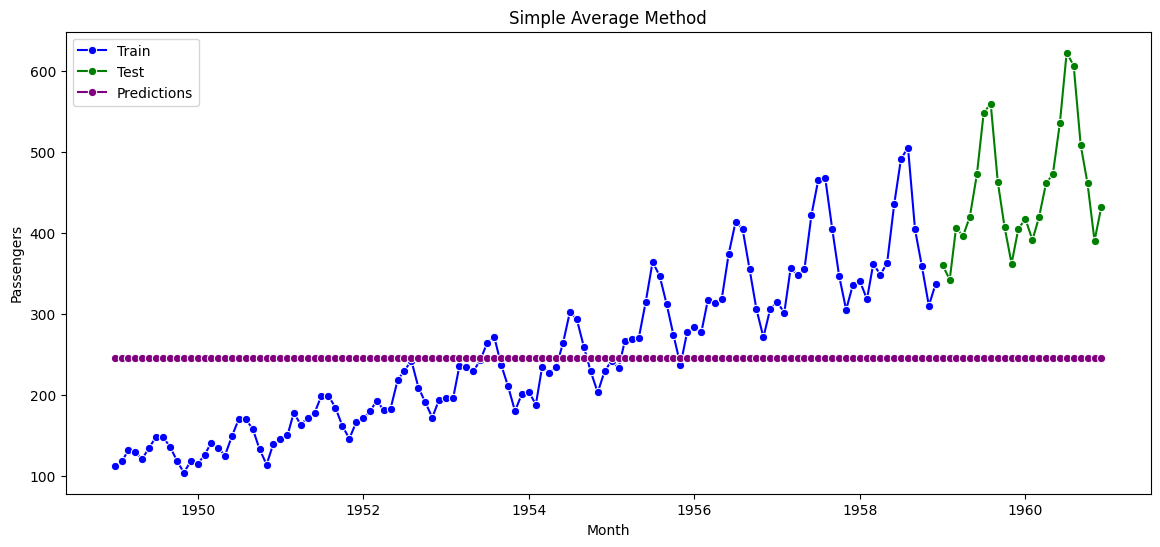

In [29]:
# Visualise the time series data and the predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', label = 'Train', marker = 'o', color = 'blue')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', label = 'Test', marker = 'o', color = 'green')
sns.lineplot(data = df, x = 'Month', y = y_pred_sa, label = 'Predictions', marker = 'o', color = 'purple')
plt.legend(loc = 'best')
plt.title('Simple Average Method');

In [30]:
# Summarise the performance of the model on the test data using RMSE and MAPE
y_pred_sa_list = [y_pred_sa] * len(df_test)

rmse = np.sqrt(mean_squared_error(y_true = df_test['Passengers'], y_pred = y_pred_sa_list))
mape = np.mean(np.abs(df_test['Passengers'] - y_pred_sa_list) / df_test['Passengers']) * 100

rmse = np.round(rmse, 2)
mape = np.round(mape, 2)

performance_df_temp = pd.DataFrame(index = [0],
                                   data = {'Model': 'Simple Average', 'RMSE': rmse, 'MAPE': mape})

performance_df_temp.set_index(keys = 'Model', inplace = True)

performance_df = pd.concat(objs = [performance_df, performance_df_temp])

performance_df

,RMSE,MAPE
Model,,
Linear Regression,74.79,11.22
Naive,137.33,23.58
Simple Average,219.44,44.23


### 2.4 Simple Moving Average Method


In [31]:
# Generate predictions for the full series using a simple moving average with a window size of 3
ma_window = 3
y_pred_sma = df['Passengers'].rolling(ma_window).mean()
y_pred_sma.iloc[train_len:] = y_pred_sma.iloc[train_len - 1]


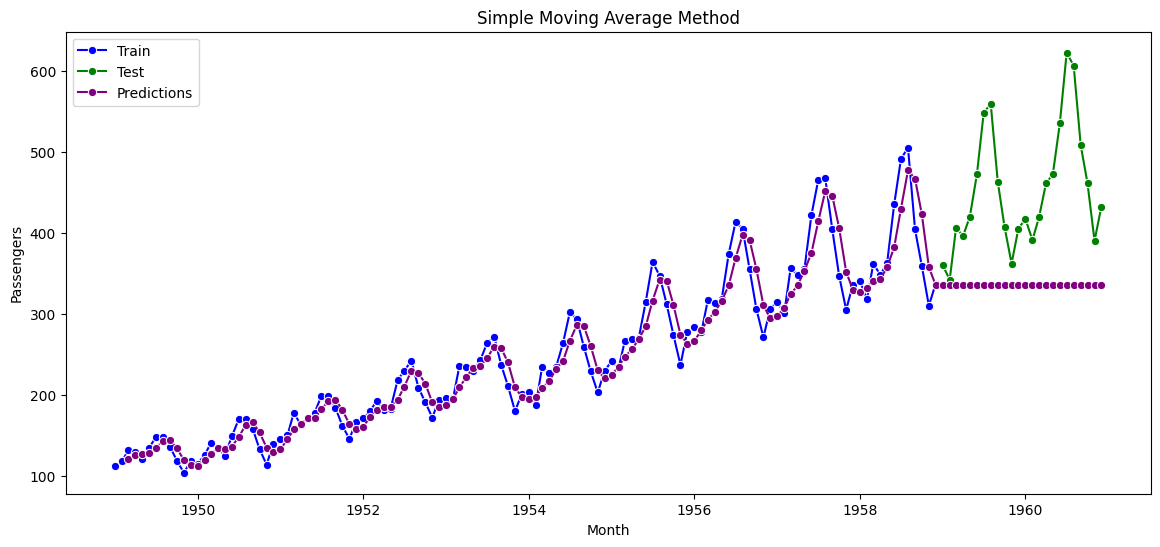

In [32]:
# Visualise the time series data and the predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', label = 'Train', marker = 'o', color = 'blue')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', label = 'Test', marker = 'o', color = 'green')
sns.lineplot(data = df, x = 'Month', y = y_pred_sma, label = 'Predictions', marker = 'o', color = 'purple')
plt.legend(loc = 'best')
plt.title('Simple Moving Average Method');

In [33]:
# Summarise the performance of the model on the test data using RMSE and MAPE
y_pred_sma_list = [y_pred_sma.iloc[train_len]] * len(df_test)

rmse = np.sqrt(mean_squared_error(y_true = df_test['Passengers'], y_pred = y_pred_sma_list))
mape = np.mean(np.abs(df_test['Passengers'] - y_pred_sma_list) / df_test['Passengers']) * 100

rmse = np.round(rmse, 2)
mape = np.round(mape, 2)

performance_df_temp = pd.DataFrame(index = [0],
                                   data = {'Model': 'Simple Moving Average', 'RMSE': rmse, 'MAPE': mape})

performance_df_temp.set_index(keys = 'Model', inplace = True)

performance_df = pd.concat(objs = [performance_df, performance_df_temp])

performance_df

,RMSE,MAPE
Model,,
Linear Regression,74.79,11.22
Naive,137.33,23.58
Simple Average,219.44,44.23
Simple Moving Average,138.73,23.96


## Part 3 — Exponential Smoothing Models
Next, I applied exponential smoothing techniques, which weight recent observations more heavily than older ones: Simple exponential smoothing, Holt's method, and both variants of Holt-Winters' seasonal smoothing.


### 3.1 Simple Exponential Smoothing


In [34]:
# Create a model instance for the training data using the 'SimpleExpSmoothing()' method
model = SimpleExpSmoothing(df_train['Passengers'], initialization_method = 'estimated')

In [35]:
# Fit the simple exponential smoothing model on the training data, letting statsmodels optimise the smoothing parameter
model = model.fit(optimized = True)


In [36]:
# Obtain predictions for the test data using the '.forecast()' method
y_pred_ses = model.forecast(len(df_test))

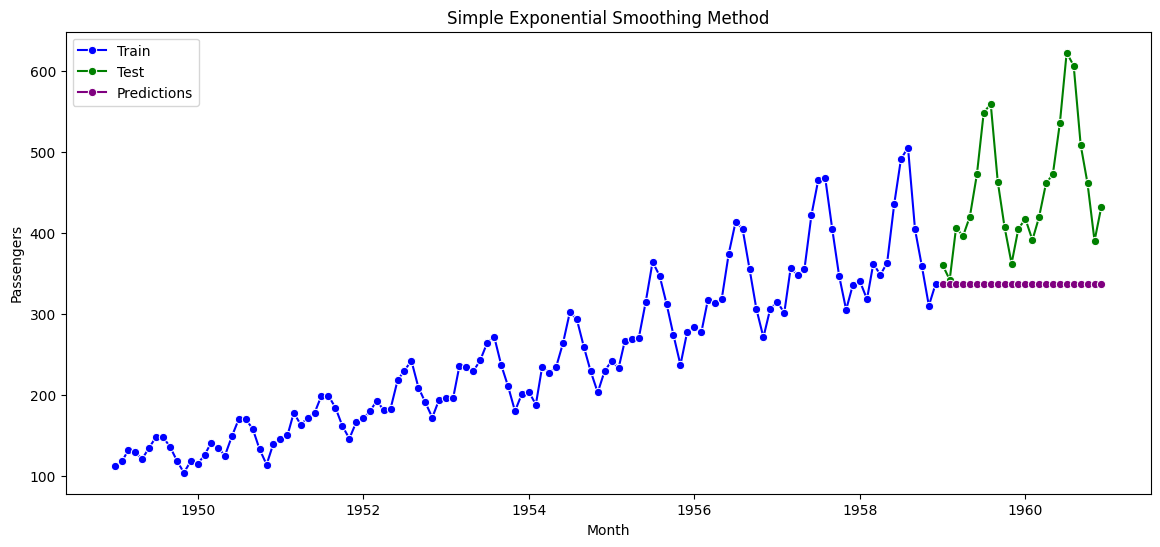

In [37]:
# Visualise the time series data and the predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', label = 'Train', marker = 'o', color = 'blue')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', label = 'Test', marker = 'o', color = 'green')
sns.lineplot(data = df, x = 'Month', y = y_pred_ses, label = 'Predictions', marker = 'o', color = 'purple')
plt.legend(loc = 'best')
plt.title('Simple Exponential Smoothing Method');

In [38]:
# Summarise the performance of the model on the test data using RMSE and MAPE
y_pred_ses_list = [y_pred_ses.iloc[0]] * len(df_test)

rmse = np.sqrt(mean_squared_error(y_true = df_test['Passengers'], y_pred = y_pred_ses_list))
mape = np.mean(np.abs(df_test['Passengers'] - y_pred_ses_list) / df_test['Passengers']) * 100

rmse = np.round(rmse, 2)
mape = np.round(mape, 2)

performance_df_temp = pd.DataFrame(index = [0],
                                   data = {'Model': 'Simple Exponential Smoothing', 'RMSE': rmse, 'MAPE': mape})

performance_df_temp.set_index(keys = 'Model', inplace = True)

performance_df = pd.concat(objs = [performance_df, performance_df_temp])

performance_df

,RMSE,MAPE
Model,,
Linear Regression,74.79,11.22
Naive,137.33,23.58
Simple Average,219.44,44.23
Simple Moving Average,138.73,23.96
Simple Exponential Smoothing,137.33,23.58


### 3.2 Holt's Method


In [39]:
# Fit Holt's method: additive trend, no seasonal component, with a 12-month seasonal period reference
model = ExponentialSmoothing(df_train['Passengers'], seasonal_periods = 12, trend = 'additive', seasonal = None)


In [40]:
# Fit the model, optimising parameters automatically
model = model.fit(optimized = True)


In [41]:
# Obtain predictions for the test data using the '.forecast()' method
y_pred_hes = model.forecast(len(df_test))

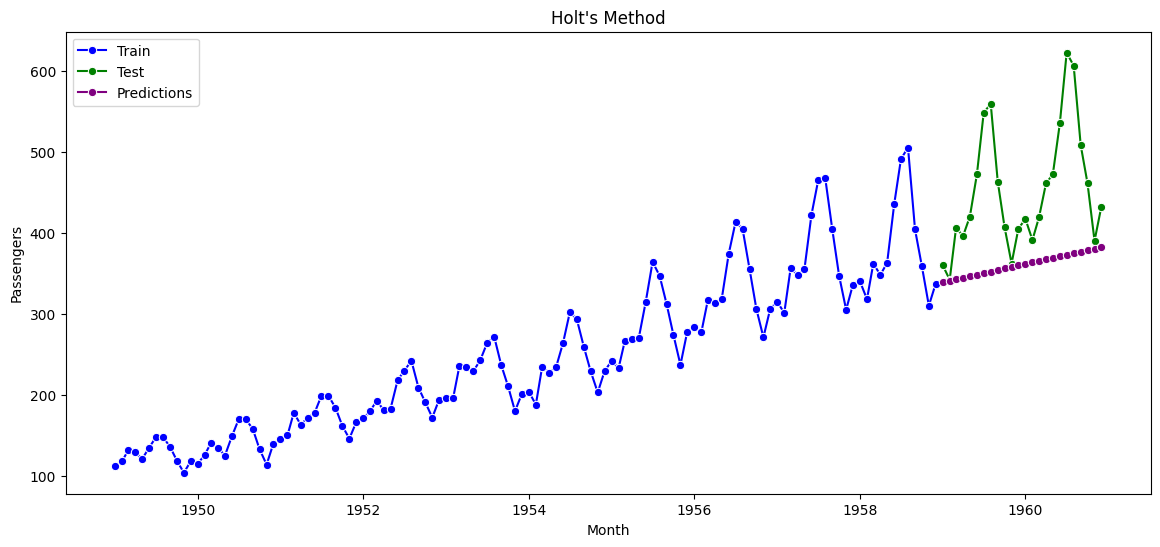

In [42]:
# Visualise the time series data and the predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', label = 'Train', marker = 'o', color = 'blue')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', label = 'Test', marker = 'o', color = 'green')
sns.lineplot(data = df_test, x = 'Month', y = y_pred_hes, label = 'Predictions', marker = 'o', color = 'purple')
plt.legend(loc = 'best')
plt.title('Holt\'s Method');

In [43]:
# Summarise the performance of the model on the test data using RMSE and MAPE
y_pred_hes_list = y_pred_hes

rmse = np.sqrt(mean_squared_error(y_true = df_test['Passengers'], y_pred = y_pred_hes_list))
mape = np.mean(np.abs(df_test['Passengers'] - y_pred_hes_list) / df_test['Passengers']) * 100

rmse = np.round(rmse, 2)
mape = np.round(mape, 2)

performance_df_temp = pd.DataFrame(index = [0],
                                   data = {'Model': 'Holt\'s', 'RMSE': rmse, 'MAPE': mape})

performance_df_temp.set_index(keys = 'Model', inplace = True)

performance_df = pd.concat(objs = [performance_df, performance_df_temp])

performance_df

,RMSE,MAPE
Model,,
Linear Regression,74.79,11.22
Naive,137.33,23.58
Simple Average,219.44,44.23
Simple Moving Average,138.73,23.96
Simple Exponential Smoothing,137.33,23.58
Holt's,115.70,18.41


### 3.3 Holt-Winters' Additive Method


In [44]:
# Fit Holt-Winters' additive method: additive trend and additive seasonality, 12-month seasonal period
model = ExponentialSmoothing(df_train['Passengers'], seasonal_periods = 12, trend = 'additive', seasonal = 'additive')


In [45]:
# Fit the model, optimising parameters automatically
model = model.fit(optimized = True)


In [46]:
# Obtain predictions for the test data using the '.forecast()' method
y_pred_hwa = model.forecast(len(df_test))

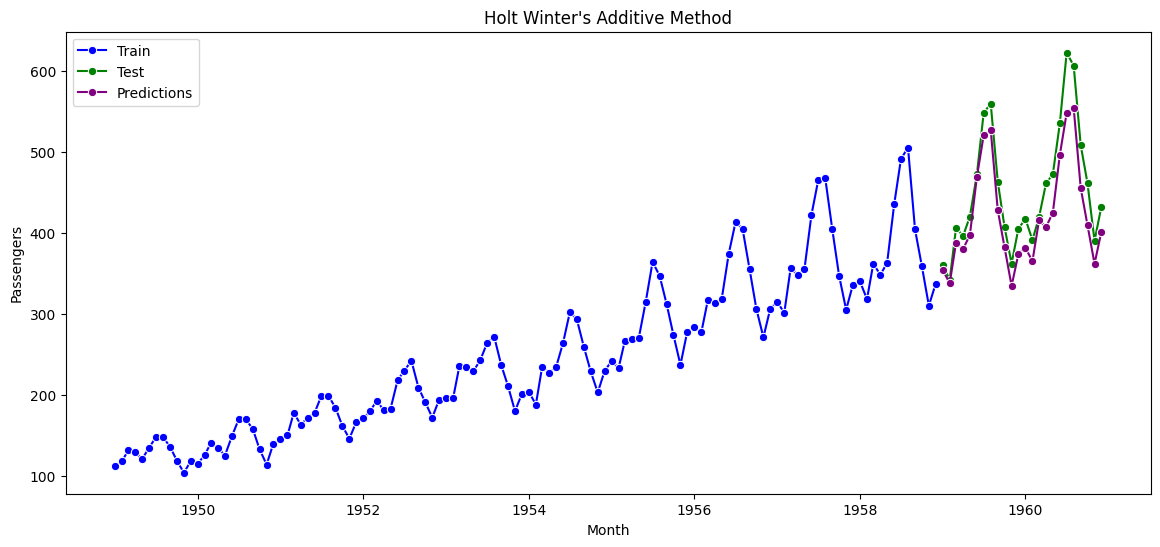

In [47]:
# Visualise the time series data and the predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', label = 'Train', marker = 'o', color = 'blue')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', label = 'Test', marker = 'o', color = 'green')
sns.lineplot(data = df_test, x = 'Month', y = y_pred_hwa, label = 'Predictions', marker = 'o', color = 'purple')
plt.legend(loc = 'best')
plt.title('Holt Winter\'s Additive Method');

In [48]:
# Summarise the performance of the model on the test data using RMSE and MAPE
y_pred_hwa_list = y_pred_hwa

rmse = np.sqrt(mean_squared_error(y_true = df_test['Passengers'], y_pred = y_pred_hwa_list))
mape = np.mean(np.abs(df_test['Passengers'] - y_pred_hwa_list) / df_test['Passengers']) * 100

rmse = np.round(rmse, 2)
mape = np.round(mape, 2)

performance_df_temp = pd.DataFrame(index = [0],
                                   data = {'Model': 'Holt Winter\'s Additive', 'RMSE': rmse, 'MAPE': mape})

performance_df_temp.set_index(keys = 'Model', inplace = True)

performance_df = pd.concat(objs = [performance_df, performance_df_temp])

performance_df

,RMSE,MAPE
Model,,
Linear Regression,74.79,11.22
Naive,137.33,23.58
Simple Average,219.44,44.23
Simple Moving Average,138.73,23.96
Simple Exponential Smoothing,137.33,23.58
Holt's,115.70,18.41
Holt Winter's Additive,35.76,6.64


### 3.4 Holt-Winters' Multiplicative Method


In [49]:
# Fit Holt-Winters' multiplicative method: additive trend and multiplicative seasonality, 12-month seasonal period
model = ExponentialSmoothing(df_train['Passengers'], seasonal_periods = 12, trend = 'additive', seasonal = 'multiplicative')


In [50]:
# Fit the model, optimising parameters automatically
model = model.fit(optimized = True)


In [51]:
# Obtain predictions for the test data using the '.forecast()' method
y_pred_hwm = model.forecast(len(df_test))

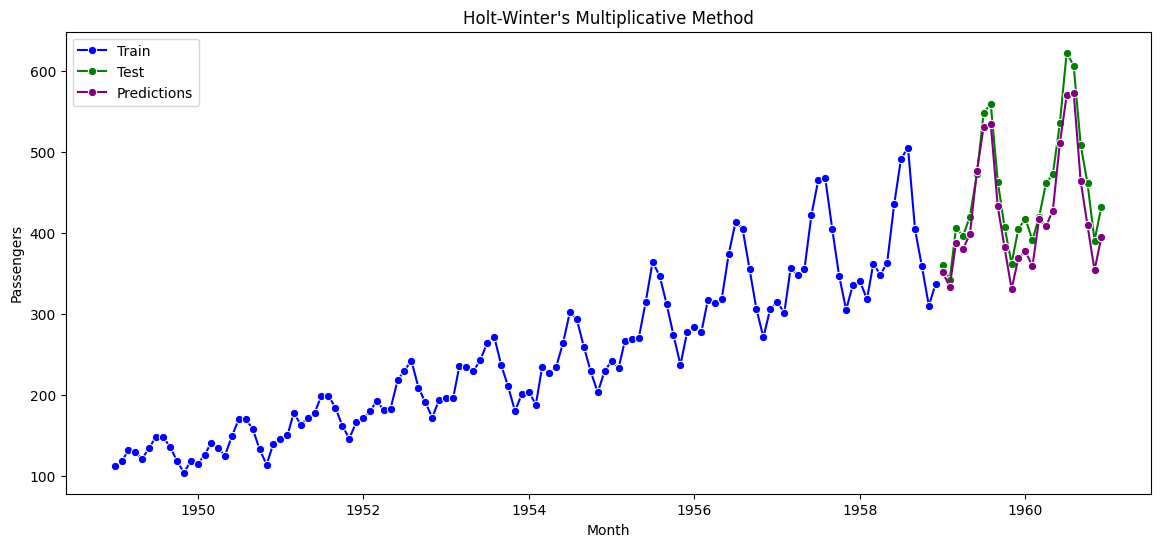

In [52]:
# Visualise the time series data and the predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', label = 'Train', marker = 'o', color = 'blue')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', label = 'Test', marker = 'o', color = 'green')
sns.lineplot(data = df_test, x = 'Month', y = y_pred_hwm, label = 'Predictions', marker = 'o', color = 'purple')
plt.legend(loc = 'best')
plt.title('Holt-Winter\'s Multiplicative Method');

In [53]:
# Summarise the performance of the model on the test data using RMSE and MAPE
y_pred_hwm_list = y_pred_hwm

rmse = np.sqrt(mean_squared_error(y_true = df_test['Passengers'], y_pred = y_pred_hwm_list))
mape = np.mean(np.abs(df_test['Passengers'] - y_pred_hwm_list) / df_test['Passengers']) * 100

rmse = np.round(rmse, 2)
mape = np.round(mape, 2)

performance_df_temp = pd.DataFrame(index = [0],
                                   data = {'Model': 'Holt Winter\'s Multiplicative', 'RMSE': rmse, 'MAPE': mape})

performance_df_temp.set_index(keys = 'Model', inplace = True)

performance_df = pd.concat(objs = [performance_df, performance_df_temp])

performance_df

,RMSE,MAPE
Model,,
Linear Regression,74.79,11.22
Naive,137.33,23.58
Simple Average,219.44,44.23
Simple Moving Average,138.73,23.96
Simple Exponential Smoothing,137.33,23.58
Holt's,115.70,18.41
Holt Winter's Additive,35.76,6.64
Holt Winter's Multiplicative,32.49,6.39


## Part 4 — Autoregressive Models
Finally, I built the autoregressive family of models, which explicitly model the time-dependent structure in the data: AR, MA, ARMA, ARIMA, and SARIMA.


### 4.0 Transformation and Differencing


In [54]:
# Apply a Box-Cox transformation (lambda = 0, equivalent to a log transform) to stabilise variance ahead of AR-family modelling
df_boxcox = pd.Series(boxcox(df_train['Passengers'], lmbda = 0), index = df_train.index)


In [55]:
# Apply the differencing transformation on the Box-Cox transformed training data
df_boxcox_diff = df_boxcox.diff().dropna()

### 4.1 Autoregressive (AR) Method


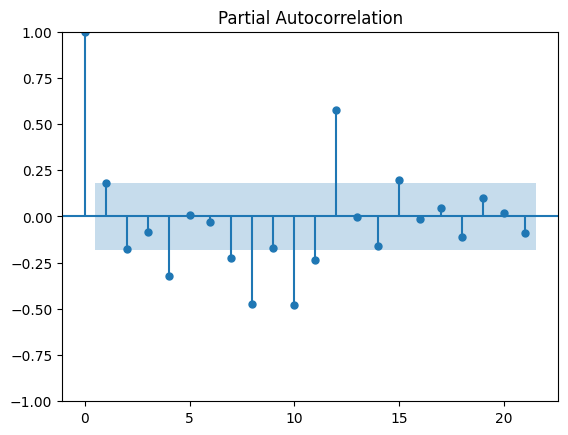

In [56]:
# Inspect partial autocorrelation on the differenced (stationary) series to help choose an AR lag order
plot_pacf(df_boxcox_diff);


In [57]:
# Fit an AR(7) model — lag order chosen from the PACF plot above
# ARIMA(7, 0, 0) is equivalent to AR(7)
ar_model = ARIMA(df_boxcox, order = (7, 0, 0))
ar_model = ar_model.fit()
ar_model.params


,0
const,5.379620
ar.L1,1.194165
ar.L2,-0.414759
ar.L3,0.205408
ar.L4,-0.328258
ar.L5,0.367629
ar.L6,-0.045926
ar.L7,0.006199
sigma2,0.009235


In [58]:
# Obtain predictions from the AR model for the testing data indices using the '.predict()' method
ar_model_preds = ar_model.predict(start = df_test.index[0], end = df_test.index[-1])

In [59]:
# Combine predictions with the original series to prepare for inverse transformation
# No differencing was applied for the AR model, so we work directly from df_boxcox
df_boxcox_preds = pd.concat(objs = [df_boxcox, ar_model_preds])


In [60]:
# The AR(7) model needed no differencing, so df_boxcox_preds is already on the Box-Cox scale — no reversal needed here
df_boxcox_preds = df_boxcox_preds
df_boxcox_preds = df_boxcox_preds


In [61]:
# Reverse the Box-Cox transformation that was done on the data by exponentiating the values in 'df_boxcox_preds'
df_preds = np.exp(df_boxcox_preds)

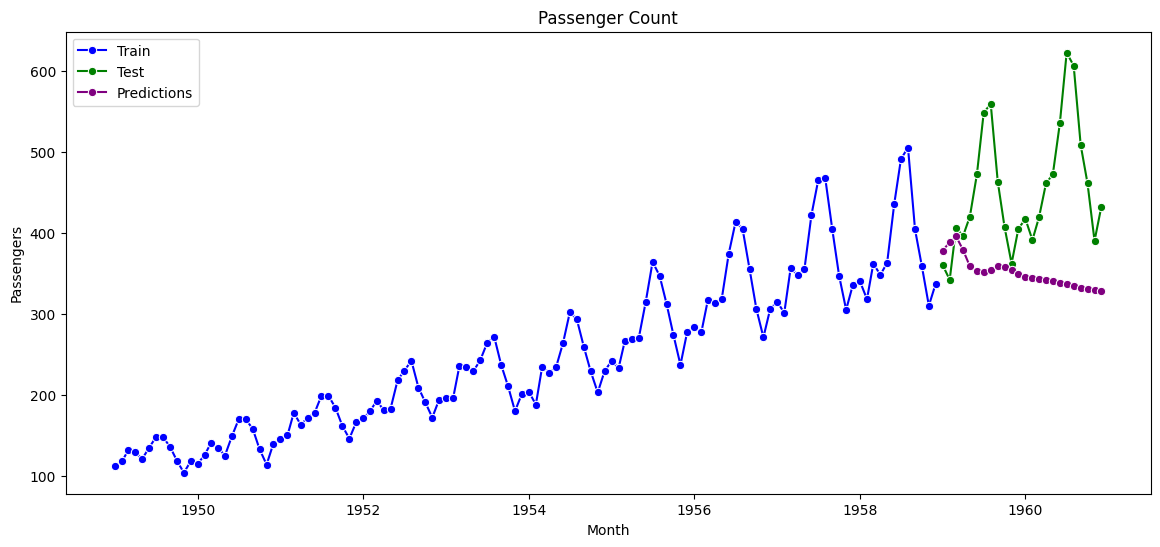

In [62]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_preds.index[train_len:], y = df_preds.values[train_len:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Passenger Count');

In [63]:
# Summarise the performance of the model on the test data using RMSE and MAPE
rmse = np.sqrt(mean_squared_error(y_true = df_test['Passengers'], y_pred = df_preds[train_len:]))
mape = np.mean(np.abs(df_test['Passengers'].values - df_preds[train_len:].values) / df_test['Passengers'].values) * 100

rmse = np.round(rmse, 2)
mape = np.round(mape, 2)

performance_df_temp = pd.DataFrame(index = [0],
                                   data = {'Model': 'AR', 'RMSE': rmse, 'MAPE': mape})

performance_df_temp.set_index(keys = 'Model', inplace = True)

performance_df = pd.concat(objs = [performance_df, performance_df_temp])

performance_df

,RMSE,MAPE
Model,,
Linear Regression,74.79,11.22
Naive,137.33,23.58
Simple Average,219.44,44.23
Simple Moving Average,138.73,23.96
Simple Exponential Smoothing,137.33,23.58
Holt's,115.70,18.41
Holt Winter's Additive,35.76,6.64
Holt Winter's Multiplicative,32.49,6.39
AR,132.17,21.66


### 4.2 Moving Average (MA) Method


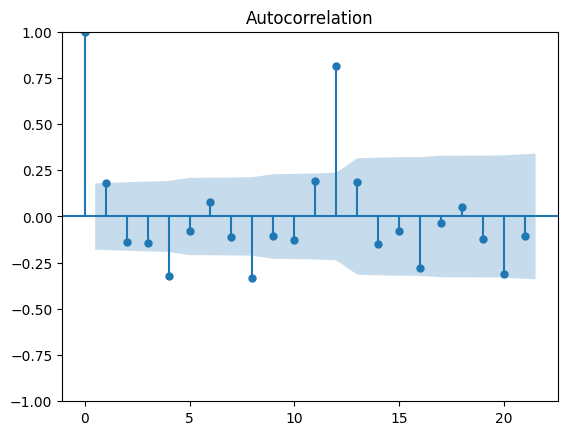

In [64]:
# Inspect autocorrelation on the differenced series to help choose an MA lag order
plot_acf(df_boxcox_diff);


In [65]:
# Fit an MA(4) model — lag order chosen from the ACF plot above
# ARIMA(0, 0, 4) is equivalent to MA(4)
ma_model = ARIMA(df_boxcox_diff, order = (0, 0, 4))
ma_model = ma_model.fit()
ma_model.params


,0
const,0.010567
ma.L1,0.018947
ma.L2,-0.329550
ma.L3,-0.221077
ma.L4,-0.448495
sigma2,0.007474


In [66]:
# Obtain predictions from the MA model for the testing data indices using the '.predict()' method
ma_model_preds = ma_model.predict(start = df_test.index[0], end = df_test.index[-1])

In [67]:
# Append 'ma_model_preds' with 'df_boxcox_diff' to prepare the data for inverse transformation
df_boxcox_diff_preds = pd.concat(objs = [df_boxcox_diff, ma_model_preds])

In [68]:
# Reverse the differencing by cumulatively summing and adding back the original starting value
df_boxcox_preds = df_boxcox_diff_preds.cumsum() + df_boxcox.iloc[0]
df_boxcox_preds = pd.concat(objs = [pd.Series([df_boxcox.iloc[0]], index = [df_boxcox.index[0]]), df_boxcox_preds])


In [69]:
# Reverse the Box-Cox transformation that was done on the data by exponentiating the values in 'df_boxcox_preds'
df_preds = np.exp(df_boxcox_preds)

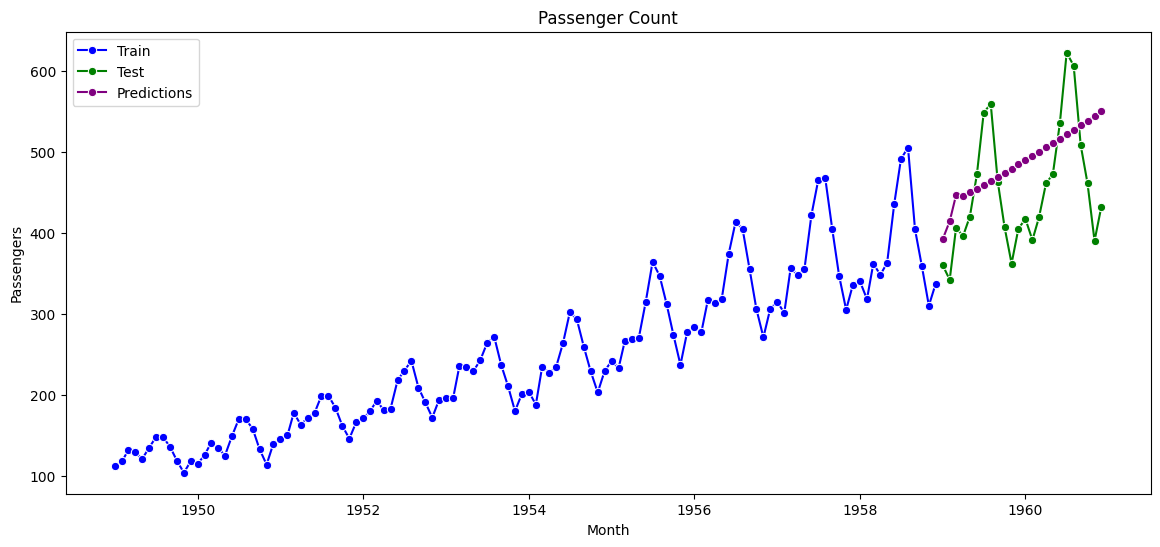

In [70]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_preds.index[train_len:], y = df_preds.values[train_len:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Passenger Count');

In [71]:
# Summarise the performance of the model on the test data using RMSE and MAPE
rmse = np.sqrt(mean_squared_error(y_true = df_test['Passengers'], y_pred = df_preds[train_len:]))
mape = np.mean(np.abs(df_test['Passengers'].values - df_preds[train_len:].values) / df_test['Passengers'].values) * 100

rmse = np.round(rmse, 2)
mape = np.round(mape, 2)

performance_df_temp = pd.DataFrame(index = [0],
                                   data = {'Model': 'MA', 'RMSE': rmse, 'MAPE': mape})

performance_df_temp.set_index(keys = 'Model', inplace = True)

performance_df = pd.concat(objs = [performance_df, performance_df_temp])

performance_df

,RMSE,MAPE
Model,,
Linear Regression,74.79,11.22
Naive,137.33,23.58
Simple Average,219.44,44.23
Simple Moving Average,138.73,23.96
Simple Exponential Smoothing,137.33,23.58
Holt's,115.70,18.41
Holt Winter's Additive,35.76,6.64
Holt Winter's Multiplicative,32.49,6.39
AR,132.17,21.66


### 4.3 Autoregressive Moving Average (ARMA) Method


In [72]:
# Fit an ARMA(7, 4) model combining the AR and MA lag orders identified above
# ARIMA(7, 0, 4) is equivalent to ARMA(7, 4)
arma_model = ARIMA(df_boxcox_diff, order = (7, 0, 4))
arma_model = arma_model.fit()
arma_model.params


,0
const,0.010650
ar.L1,-0.388966
ar.L2,-0.192524
ar.L3,0.015534
ar.L4,-0.081752
ar.L5,-0.417276
ar.L6,0.008627
ar.L7,-0.216563
ma.L1,0.448005
ma.L2,-0.071848


In [73]:
# Obtain predictions from the ARMA model for the testing data indices using the '.predict()' method
arma_model_preds = arma_model.predict(start = df_test.index[0], end = df_test.index[-1])

In [74]:
# Append 'arma_model_preds' with 'df_boxcox_diff' to prepare the data for inverse transformation
df_boxcox_diff_preds = pd.concat(objs = [df_boxcox_diff, arma_model_preds])

In [75]:
# Reverse the differencing by cumulatively summing and adding back the original starting value
df_boxcox_preds = df_boxcox_diff_preds.cumsum() + df_boxcox.iloc[0]
df_boxcox_preds = pd.concat(objs = [pd.Series([df_boxcox.iloc[0]], index = [df_boxcox.index[0]]), df_boxcox_preds])


In [76]:
# Reverse the Box-Cox transformation that was done on the data by exponentiating the values in 'df_boxcox_preds'
df_preds = np.exp(df_boxcox_preds)

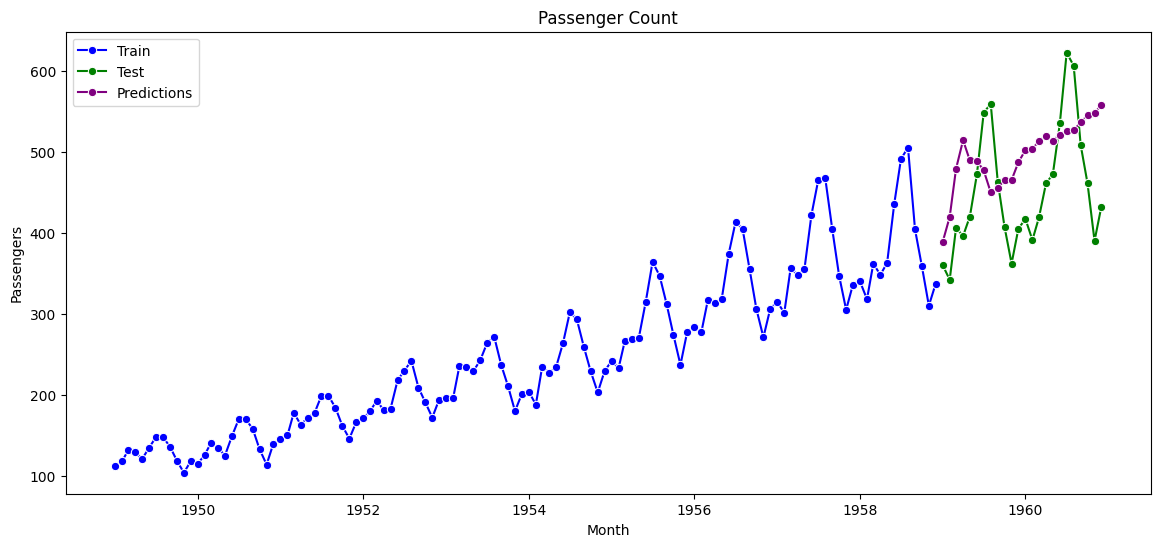

In [77]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_preds.index[train_len:], y = df_preds.values[train_len:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Passenger Count');

In [78]:
# Summarise the performance of the model on the test data using RMSE and MAPE
rmse = np.sqrt(mean_squared_error(y_true = df_test['Passengers'], y_pred = df_preds[train_len:]))
mape = np.mean(np.abs(df_test['Passengers'].values - df_preds[train_len:].values) / df_test['Passengers'].values) * 100

rmse = np.round(rmse, 2)
mape = np.round(mape, 2)

performance_df_temp = pd.DataFrame(index = [0],
                                   data = {'Model': 'ARMA', 'RMSE': rmse, 'MAPE': mape})

performance_df_temp.set_index(keys = 'Model', inplace = True)

performance_df = pd.concat(objs = [performance_df, performance_df_temp])

performance_df

,RMSE,MAPE
Model,,
Linear Regression,74.79,11.22
Naive,137.33,23.58
Simple Average,219.44,44.23
Simple Moving Average,138.73,23.96
Simple Exponential Smoothing,137.33,23.58
Holt's,115.70,18.41
Holt Winter's Additive,35.76,6.64
Holt Winter's Multiplicative,32.49,6.39
AR,132.17,21.66


### 4.4 Autoregressive Integrated Moving Average (ARIMA) Method


In [79]:
# Fit an ARIMA(7, 1, 4) model, letting the model handle differencing internally (d = 1) on the Box-Cox series
arima_model = ARIMA(df_boxcox, order = (7, 1, 4))
arima_model = arima_model.fit()
arima_model.params


,0
ar.L1,0.867114
ar.L2,-0.734540
ar.L3,0.531075
ar.L4,-0.780691
ar.L5,0.252749
ar.L6,-0.020601
ar.L7,-0.479596
ma.L1,-0.963740
ma.L2,0.463657
ma.L3,-0.770818


In [80]:
# Obtain predictions from the ARIMA model for the testing data indices using the '.predict()' method
arima_model_preds = arima_model.predict(start = df_test.index[0], end = df_test.index[-1])

In [81]:
# Append 'arima_model_preds' with 'df_boxcox' to prepare the data for inverse transformation
df_boxcox_preds = pd.concat(objs = [df_boxcox, arima_model_preds])

In [82]:
# Reverse the Box-Cox transformation that was done on the data by exponentiating the values in 'df_boxcox_preds'
df_preds = np.exp(df_boxcox_preds)

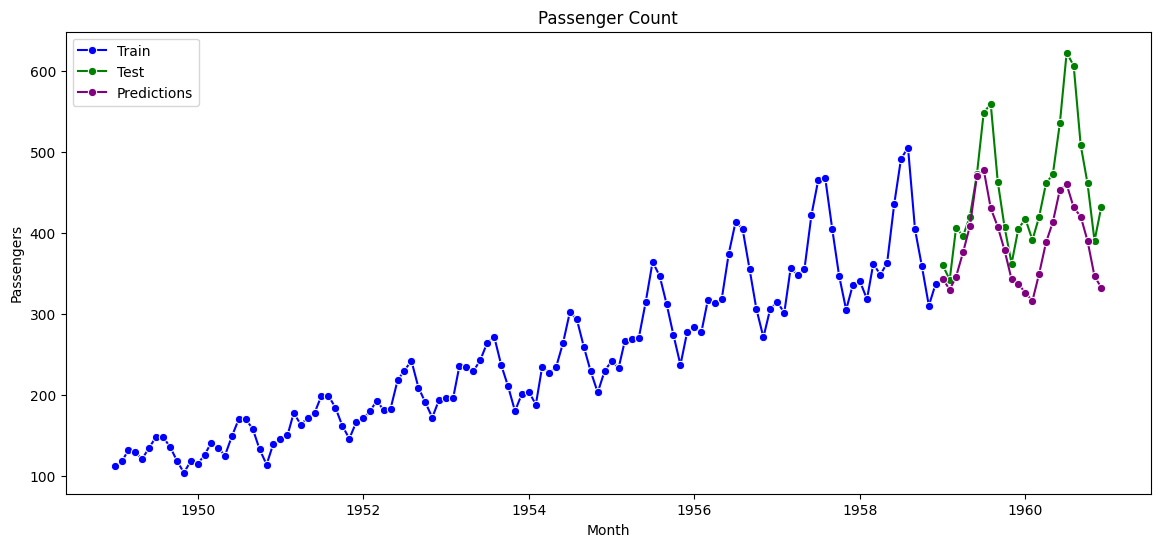

In [83]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_preds.index[train_len:], y = df_preds.values[train_len:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Passenger Count');

In [84]:
# Summarise the performance of the model on the test data using RMSE and MAPE
rmse = np.sqrt(mean_squared_error(y_true = df_test['Passengers'], y_pred = df_preds[train_len:]))
mape = np.mean(np.abs(df_test['Passengers'].values - df_preds[train_len:].values) / df_test['Passengers'].values) * 100

rmse = np.round(rmse, 2)
mape = np.round(mape, 2)

performance_df_temp = pd.DataFrame(index = [0],
                                   data = {'Model': 'ARIMA', 'RMSE': rmse, 'MAPE': mape})

performance_df_temp.set_index(keys = 'Model', inplace = True)

performance_df = pd.concat(objs = [performance_df, performance_df_temp])

performance_df

,RMSE,MAPE
Model,,
Linear Regression,74.79,11.22
Naive,137.33,23.58
Simple Average,219.44,44.23
Simple Moving Average,138.73,23.96
Simple Exponential Smoothing,137.33,23.58
Holt's,115.70,18.41
Holt Winter's Additive,35.76,6.64
Holt Winter's Multiplicative,32.49,6.39
AR,132.17,21.66


### 4.5 Seasonal Autoregressive Integrated Moving Average (SARIMA) Method


In [85]:
# Fit a SARIMA model with non-seasonal order (7, 1, 4) and seasonal order (0, 1, 0, 3), adding a seasonal differencing component on top of ARIMA
sarima_model = SARIMAX(df_boxcox, order = (7, 1, 4), seasonal_order = (0, 1, 0, 3))
sarima_model = sarima_model.fit(disp = False)
sarima_model.params


,0
ar.L1,-0.096277
ar.L2,0.087551
ar.L3,-0.465207
ar.L4,-0.316908
ar.L5,0.199330
ar.L6,-0.325531
ar.L7,-0.138277
ma.L1,0.460731
ma.L2,-0.003859
ma.L3,-0.939489


In [86]:
# Obtain predictions from the SARIMA model for the testing data indices using the '.predict()' method
sarima_model_preds = sarima_model.predict(start = df_test.index[0], end = df_test.index[-1])

In [87]:
# Append 'sarima_model_preds' with 'df_boxcox' to prepare the data for inverse transformation
df_boxcox_preds = pd.concat(objs = [df_boxcox, sarima_model_preds])

In [88]:
# Reverse the Box-Cox transformation that was done on the data by exponentiating the values in 'df_boxcox_preds'
df_preds = np.exp(df_boxcox_preds)

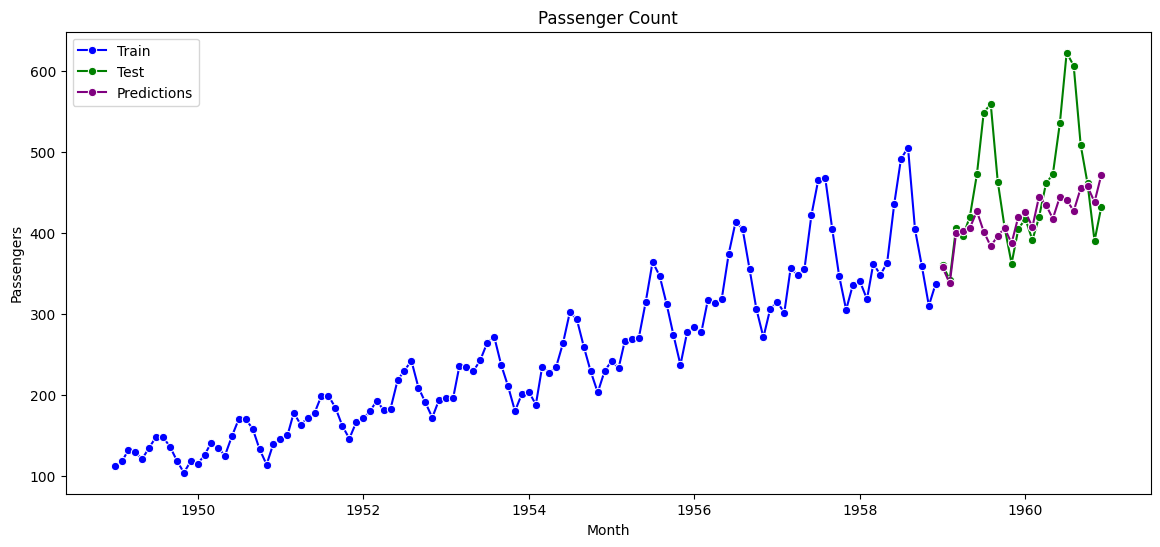

In [89]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Month', y = 'Passengers', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test, x = 'Month', y = 'Passengers', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_preds.index[train_len:], y = df_preds.values[train_len:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Passenger Count');

In [90]:
# Summarise the performance of the model on the test data using RMSE and MAPE
rmse = np.sqrt(mean_squared_error(y_true = df_test['Passengers'], y_pred = df_preds[train_len:]))
mape = np.mean(np.abs(df_test['Passengers'].values - df_preds[train_len:].values) / df_test['Passengers'].values) * 100

rmse = np.round(rmse, 2)
mape = np.round(mape, 2)

performance_df_temp = pd.DataFrame(index = [0],
                                   data = {'Model': 'SARIMA', 'RMSE': rmse, 'MAPE': mape})

performance_df_temp.set_index(keys = 'Model', inplace = True)

performance_df = pd.concat(objs = [performance_df, performance_df_temp])

performance_df

,RMSE,MAPE
Model,,
Linear Regression,74.79,11.22
Naive,137.33,23.58
Simple Average,219.44,44.23
Simple Moving Average,138.73,23.96
Simple Exponential Smoothing,137.33,23.58
Holt's,115.70,18.41
Holt Winter's Additive,35.76,6.64
Holt Winter's Multiplicative,32.49,6.39
AR,132.17,21.66
